# Intelligent Biodiversity Risk Assessment System
**SRN:** PES1PG25CA033 | **Name:** Avirup Shyam  
**Domain:** Agriculture | **SDG Goal:** Life On Land (SDG 15)  
**Algorithm:** Logistic Regression (Supervised Classification)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [1]:
import pandas as pd
df = pd.read_csv('covtype.csv')
df.sample(10000, random_state=42).to_csv('covtype_small.csv', index=False)
print("Done!")

Done!


In [17]:
feature_cols = [
    'Elevation',                          # height above sea level
    'Aspect',                             # compass direction of slope
    'Slope',                              # steepness of terrain
    'Horizontal_Distance_To_Hydrology',   # distance to nearest water source
    'Vertical_Distance_To_Hydrology',     # elevation difference to water
    'Horizontal_Distance_To_Roadways',    # human activity proximity
    'Hillshade_9am',                      # shade level at 9am
    'Hillshade_Noon',                     # shade level at noon
    'Hillshade_3pm',                      # shade level at 3pm
    'Horizontal_Distance_To_Fire_Points'  # fire risk proximity
]

X = df[feature_cols]
print("Selected features shape:", X.shape)

Selected features shape: (581012, 10)


In [20]:
#defined
risk_score = (
    (df['Elevation'] < df['Elevation'].quantile(0.33)).astype(int) +
    (df['Slope'] > df['Slope'].quantile(0.66)).astype(int) +
    (df['Horizontal_Distance_To_Roadways'] < df['Horizontal_Distance_To_Roadways'].quantile(0.33)).astype(int) +
    (df['Horizontal_Distance_To_Fire_Points'] < df['Horizontal_Distance_To_Fire_Points'].quantile(0.33)).astype(int)
)


def assign_risk(score):
    if score <= 1:
        return 0   
    elif score == 2:
        return 1  
    else:
        return 2   

y = risk_score.apply(assign_risk)

print("Risk label distribution:")
print(y.value_counts().rename({0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}))

Risk label distribution:
Low Risk       367180
Medium Risk    115058
High Risk       98774
Name: count, dtype: int64


In [21]:
print("Missing values per feature:")
print(X.isnull().sum())

Missing values per feature:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
dtype: int64


In [22]:
sample_df = pd.concat([X, y.rename('Risk')], axis=1)

sample_df = pd.concat([
    grp.sample(min(len(grp), 3334), random_state=42)
    for _, grp in sample_df.groupby('Risk')
]).reset_index(drop=True)

X_sample = sample_df[feature_cols]
y_sample = sample_df['Risk']

print("Sampled dataset shape:", X_sample.shape)
print(y_sample.value_counts())

Sampled dataset shape: (10002, 10)
Risk
0    3334
1    3334
2    3334
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 8001
Testing samples : 2001


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("Scaling complete. Sample mean (should be ~0):", X_train_scaled.mean().round(4))

Scaling complete. Sample mean (should be ~0): 0.0


In [25]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


In [26]:
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'Medium Risk', 'High Risk']))

Accuracy: 79.36%

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.83      0.82      0.83       667
 Medium Risk       0.69      0.70      0.69       667
   High Risk       0.86      0.86      0.86       667

    accuracy                           0.79      2001
   macro avg       0.79      0.79      0.79      2001
weighted avg       0.79      0.79      0.79      2001



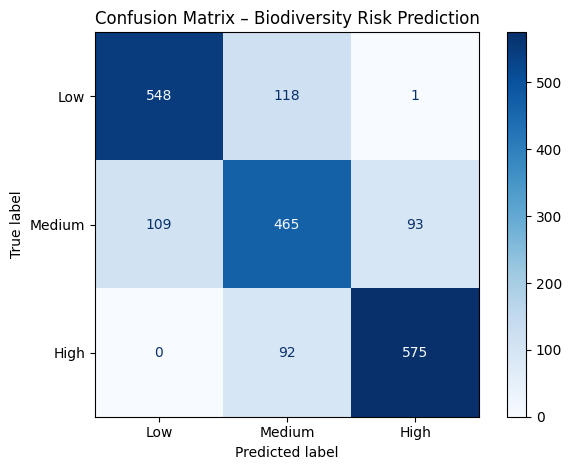

In [27]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix – Biodiversity Risk Prediction')
plt.tight_layout()
plt.show()

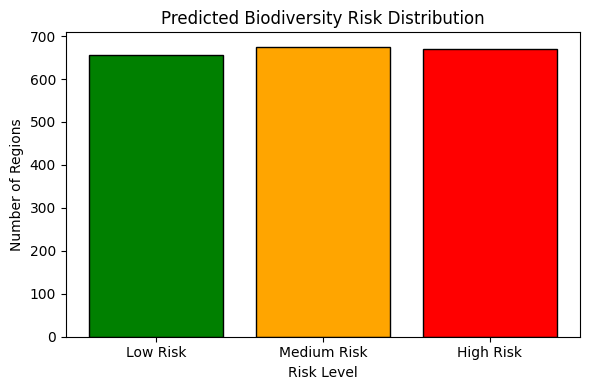

In [28]:
risk_counts = pd.Series(y_pred).value_counts().sort_index()
labels = ['Low Risk', 'Medium Risk', 'High Risk']
colors = ['green', 'orange', 'red']

plt.figure(figsize=(6, 4))
plt.bar(labels, risk_counts.values, color=colors, edgecolor='black')
plt.title('Predicted Biodiversity Risk Distribution')
plt.xlabel('Risk Level')
plt.ylabel('Number of Regions')
plt.tight_layout()
plt.show()

In [18]:
# coef_df = pd.DataFrame(
#     np.abs(model.coef_).mean(axis=0),
#     index=feature_cols,
#     columns=['Importance']
# ).sort_values('Importance', ascending=True)

# coef_df.plot(kind='barh', legend=False, color='steelblue', figsize=(7, 5))
# plt.title('Feature Importance (Logistic Regression Coefficients)')
# plt.xlabel('Mean |Coefficient|')
# plt.tight_layout()
# plt.show()

In [19]:
# sample_region = pd.DataFrame([{
#     'Elevation': 2200,
#     'Aspect': 90,
#     'Slope': 20,
#     'Horizontal_Distance_To_Hydrology': 100,
#     'Vertical_Distance_To_Hydrology': 10,
#     'Horizontal_Distance_To_Roadways': 150,   # very close to roads → higher risk
#     'Hillshade_9am': 210,
#     'Hillshade_Noon': 240,
#     'Hillshade_3pm': 150,
#     'Horizontal_Distance_To_Fire_Points': 200  # close to fire points → higher risk
# }])

# sample_scaled = scaler.transform(sample_region)
# prediction = model.predict(sample_scaled)[0]

# risk_map = {0: 'Low Risk 🟢', 1: 'Medium Risk 🟡', 2: 'High Risk 🔴'}
# print(f"Predicted Biodiversity Risk for this region: {risk_map[prediction]}")